# HydrAI — Tree-based model training

Train **Random Forest**, **Gradient Boosting**, **XGBoost**, and **AdaBoost** surrogates on PFR data.

**Prerequisites:** Run Main_2 and Main_3 so `data/processed/features_targets_*.pkl` exists.

**Steps:** Paths and flags → Load config → Load data → Features and targets → Train/test split → Train models → (optional) Hyperparameter tuning → Feature importance → (optional) Plotting trees → Export models.

**Recommendations to improve predictive performance:**
- **Tuning:** Include XGBoost in hyperparameter search (Section 7) and increase `N_ITER` (e.g. 50–100) and `CV` (e.g. 5) for more robust best params.
- **Data:** In Main_3, add physics-informed or interaction features if not already present; more (and representative) data usually helps most.
- **Stability:** Use repeated train/test splits or a fixed validation fold when tuning to reduce variance in reported metrics.
- **Ensemble:** In Main_5 or inference, consider a simple average (or weighted average) of RF, GB, and XGBoost predictions to often gain a small R²/error improvement.
- **Config:** Slightly higher `n_estimators` for GB/XGB (e.g. 150–200) when tuning is off can help; keep AdaBoost `learning_rate` modest (0.05–0.1).
- **Limited data:** With few samples, prefer a smaller **test_size** (e.g. 0.15) to keep more for training; use **tuning** so `max_depth` and `min_samples_leaf` are regularized; avoid overly complex trees. If possible, generate more simulation runs (Main_1/Main_2) to grow the dataset.

In [26]:
import os
import sys
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import xgboost as xgb

from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    AdaBoostRegressor
    )

from sklearn.multioutput import (
    MultiOutputRegressor
    )

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score,
    GridSearchCV, 
    RandomizedSearchCV
    )

from sklearn.preprocessing import (
    StandardScaler, 
    LabelEncoder
    )

from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score
    )


from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree,
)

from scipy.stats import (
    randint, 
    uniform
    )
# Project root: notebooks live under notebooks/; from there, project root is one level up
current_dir = Path(os.getcwd())
project_root = current_dir if (current_dir / 'src').exists() else current_dir.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Paths and flags

Data directory, glob for latest `features_targets_*.pkl`, and export/plot toggles.

In [27]:
# Section 1 — Paths and flags

IF_PLOT_SHOWN        = True
IF_PLOT_EXPORT       = False
IF_TREE_MODEL_EXPORT = True

# Training data (section 4)
#   TRAIN_EXIT: True | False — one sample per run at reactor exit (max relative_position)
#   TRAIN_FULL_PROFILE: True | False — all axial positions; both can be True
TRAIN_EXIT          = True
TRAIN_FULL_PROFILE  = False

# Which models to train (section 6)
#   TREE_TRAIN_MODEL_NAME: None | str | list
#     None → all four; str → e.g. 'random_forest'; list → e.g. ['random_forest', 'gradient_boosting']
#     Keys: 'random_forest', 'gradient_boosting', 'xgboost', 'adaboost'
TREE_TRAIN_MODEL_NAME = None

# Hyperparameter tuning (section 7)
#   IF_HYPERPARAM_TUNING: True | False — use param grids/distributions
#   IF_HYPERPARAM_TUNING_DETAIL: True | False — run RandomizedSearchCV (slow)
#   TUNING_METHOD: 'Random' | 'Grid'
IF_HYPERPARAM_TUNING       = True
IF_HYPERPARAM_TUNING_DETAIL = True
TUNING_METHOD              = "Random"

# Feature importance (section 8)
#   FEATURE_IMPORTANCE_METHOD: None | list — which models to extract from (None = all trained)
#   FEATURE_IMPORTANCE_METHOD_PLOT: None | str | list — which to include in plots (None = all extracted)
FEATURE_IMPORTANCE_METHOD      = None
FEATURE_IMPORTANCE_METHOD_PLOT = None

# Tree plotting (section 9)
#   TREE_PLOT_MODEL: None | str — e.g. 'random_forest', 'gradient_boosting' (None = skip)
#   TREE_PLOT_MAX_DEPTH: None | int — max depth in plot (None = full tree)
TREE_PLOT_MODEL     = None
TREE_PLOT_MAX_DEPTH = None

# Paths
EXPORT_DIR         = project_root / "models"
CONFIG_PATH        = project_root / "configs" / "ml_training_config.json"
MODELS_DIR         = project_root / "models"
PROCESSED_DATA_DIR = project_root / "data" / "processed"
PROCESSED_DATA_FILE = "features_targets_training_data_complete_*.pkl"

# Summary
_train = "all" if TREE_TRAIN_MODEL_NAME is None else TREE_TRAIN_MODEL_NAME
_fi    = "all" if FEATURE_IMPORTANCE_METHOD is None else FEATURE_IMPORTANCE_METHOD
_fi_plot = "all" if FEATURE_IMPORTANCE_METHOD_PLOT is None else FEATURE_IMPORTANCE_METHOD_PLOT
print(f"Plot: {IF_PLOT_SHOWN}  |  Export: {IF_PLOT_EXPORT}  |  Save models: {IF_TREE_MODEL_EXPORT}")
print(f"Train: {_train}  |  FI extract: {_fi}  |  FI plot: {_fi_plot}  |  Tuning: {IF_HYPERPARAM_TUNING}")

Plot: True  |  Export: False  |  Save models: True
Train: all  |  FI extract: all  |  FI plot: all  |  Tuning: True


## 2. Load config

Load hyperparameters and train/test split from `configs/ml_training_config.json`.

In [28]:
# ── Section 2: Load config ───────────────────────────────────────────────────
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config not found: {CONFIG_PATH}")
with open(CONFIG_PATH) as f:
    config = json.load(f)
TEST_SIZE = config.get("test_size", 0.2)
RANDOM_STATE = config.get("random_state", 42)
RF_CONFIG = config.get("random_forest", {})
GB_CONFIG = config.get("gradient_boosting", {})
XGB_CONFIG = config.get("xgboost", {})
ADA_CONFIG = config.get("adaboost", {})
print(f"Config loaded  |  test_size={TEST_SIZE}  |  random_state={RANDOM_STATE}")

Config loaded  |  test_size=0.2  |  random_state=42


## 3. Load data

Load latest `features_targets_*.pkl` from Main_3 into `df_features` and `df_target`.

In [29]:
# ── Section 3: Load data ────────────────────────────────────────────────────
# Main_3 exports: {'df_features': df_features, 'df_target': df_target}
pattern = str(PROCESSED_DATA_DIR / PROCESSED_DATA_FILE)
pkl_files = sorted(glob.glob(pattern), reverse=True)
if not pkl_files:
    raise FileNotFoundError(
        f"No training data (.pkl) in {PROCESSED_DATA_DIR}. Run Main_3_data_exploration_feature_engineering first."
    )

DATA_FILE = str(Path(pkl_files[0]).resolve())
loaded = pd.read_pickle(DATA_FILE)

# Keep features and targets separate (same structure as Main_3)
if isinstance(loaded, dict) and "df_features" in loaded and "df_target" in loaded:
    df_features = loaded["df_features"]
    df_target = loaded["df_target"]
else:
    raise ValueError("Expected pickle with keys 'df_features' and 'df_target'. Run Main_3 first.")

print(f"Data: {Path(DATA_FILE).name}  |  Features: {df_features.shape[0]:,} × {df_features.shape[1]}  |  Targets: {df_target.shape[0]:,} × {df_target.shape[1]}")


Data: features_targets_training_data_complete_20260116_224238.pkl  |  Features: 152,442 × 8  |  Targets: 152,442 × 319


## 4. Features and targets

Select input columns (inlet, reactor, position; optional `reactant_type`) and target columns from `df_target`. Controlled by **TRAIN_EXIT** / **TRAIN_FULL_PROFILE**: exit-only keeps one row per run at max `relative_position`; full profile keeps all axial positions.

In [30]:
# ── Section 4: Features and targets ───────────────────────────────────────────
feature_cols = [
    "initial_temperature_K",
    "initial_pressure_Pa",
    "reactor_length_m",
    "reactor_diameter_m",
    "mass_flow_rate_kgps",
    "heat_flux_Wm2",
    "z_position_m",
    "relative_position",
]
if "reactant_type" in df_features.columns:
    feature_cols.append("reactant_type")
feature_cols = [c for c in feature_cols if c in df_features.columns]

# Targets; only columns present in df_target are used
primary_targets = [
    "temperature_K", "pressure_Pa", "velocity_ms", "density_kgm3",
    "mean_molecular_weight_kgkmol", "heat_capacity_cp_JkgK", "heat_capacity_cv_JkgK",
    "enthalpy_Jkg", "thermal_conductivity_WmK",
]
target_cols = [c for c in primary_targets if c in df_target.columns]

# Columns that uniquely identify a run (everything except spatial coordinates)
run_cols = [c for c in feature_cols if c not in ("z_position_m", "relative_position")]

def _encode_reactant(X):
    le = None
    if "reactant_type" in X.columns:
        le = LabelEncoder()
        X = X.copy()
        X["reactant_type"] = le.fit_transform(X["reactant_type"].astype(str))
    return X, le

# ── Build active_datasets ─────────────────────────────────────────────────────
# Each entry: {'X': ..., 'y': ..., 'plot_feature_cols': [...], 'label': '...'}
# Controlled by TRAIN_EXIT and TRAIN_FULL_PROFILE flags set in cell 3.
active_datasets = {}

if TRAIN_EXIT and run_cols and "relative_position" in df_features.columns:
    exit_idx = df_features.groupby(run_cols, dropna=False)["relative_position"].idxmax().values
    X_exit = df_features.loc[exit_idx, feature_cols].copy()
    y_exit = df_target.loc[exit_idx, target_cols].copy()
    X_exit, le_exit = _encode_reactant(X_exit)
    # Position cols are constant at exit (relative_position=1, z=reactor_length) — not useful as features
    exit_plot_cols = [c for c in feature_cols if c not in ("z_position_m", "relative_position")]
    active_datasets['exit'] = {
        'X': X_exit, 'y': y_exit,
        'plot_feature_cols': exit_plot_cols,
        'label': 'Exit only (max relative_position per run)',
    }

if TRAIN_FULL_PROFILE:
    X_full = df_features[feature_cols].copy()
    y_full = df_target[target_cols].copy()
    X_full, le_full = _encode_reactant(X_full)
    active_datasets['full_profile'] = {
        'X': X_full, 'y': y_full,
        'plot_feature_cols': feature_cols,  # position cols are informative along the profile
        'label': 'Full profile (all axial positions)',
    }

if not active_datasets:
    raise ValueError("No training mode active. Set TRAIN_EXIT=True and/or TRAIN_FULL_PROFILE=True in cell 3.")
# ──────────────────────────────────────────────────────────────────────────────

print(f"Active modes: {list(active_datasets.keys())}  |  Features: {len(feature_cols)}  |  Targets: {len(target_cols)}")
for mode, ds in active_datasets.items():
    print(f"  [{mode}] {ds['label']}  |  {len(ds['X']):,} samples")
# Hint when data is limited (e.g. < 500 samples per mode)
N_SAMPLES_LOW = 500
for mode, ds in active_datasets.items():
    n = len(ds['X'])
    if n < N_SAMPLES_LOW:
        print(f"  [small data] [{mode}] {n} samples — consider: test_size=0.15, enable tuning (max_depth/min_samples_leaf), or add more runs.")
        break

Active modes: ['exit']  |  Features: 8  |  Targets: 9
  [exit] Exit only (max relative_position per run)  |  760 samples


## 5. Train/test split and scaling

Train/test split (80/20) and feature scaling; scaler fit on train only (reuse at inference). One split per active mode in `all_splits`.

In [31]:
# ── Section 5: Train/test split and scaling ───────────────────────────────────
# all_splits[mode] = {'X_train', 'X_test', 'y_train', 'y_test', 'X_train_s', 'X_test_s', 'scaler_X'}
all_splits = {}
for mode, ds in active_datasets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        ds['X'], ds['y'], test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    all_splits[mode] = {
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_tr, 'y_test':  y_te,
        'X_train_s': X_tr_s, 'X_test_s': X_te_s,
        'scaler_X': scaler,
    }
    print(f"  [{mode}] Train: {len(X_tr):,} ({100*(1-TEST_SIZE):.0f}%)  |  Test: {len(X_te):,} ({100*TEST_SIZE:.0f}%)")

  [exit] Train: 608 (80%)  |  Test: 152 (20%)


## 6. Train models

**MultiOutputRegressor**: one meta-estimator per algorithm (RF, GB, XGBoost, AdaBoost), each fitting one base regressor per target. Which models are trained is controlled by **TREE_TRAIN_MODEL_NAME** (None = all; str or list = only those). One set per active mode; stored in `all_models_by_mode[mode]`.

In [32]:
# ── Section 6: Train models ───────────────────────────────────────────────────
# all_models_by_mode[mode] = dict of trained models (keys from TREE_TRAIN_MODEL_NAME or all four)
ALL_MODEL_KEYS = ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']
if TREE_TRAIN_MODEL_NAME is None:
    keys_to_train = ALL_MODEL_KEYS
elif isinstance(TREE_TRAIN_MODEL_NAME, str):
    keys_to_train = [TREE_TRAIN_MODEL_NAME]
else:
    keys_to_train = list(TREE_TRAIN_MODEL_NAME)
all_models_by_mode = {}

for mode, split in all_splits.items():
    X_train_s = split['X_train_s']
    y_train   = split['y_train']
    models = {}

    if 'random_forest' in keys_to_train:
        base_rf = RandomForestRegressor(
            n_estimators=RF_CONFIG.get("n_estimators"),
            max_depth=RF_CONFIG.get("max_depth"),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        models["random_forest"] = MultiOutputRegressor(base_rf, n_jobs=-1).fit(X_train_s, y_train)
        print(f"  [{mode}] Random Forest done.")

    if 'gradient_boosting' in keys_to_train:
        base_gb = GradientBoostingRegressor(
            n_estimators=GB_CONFIG.get("n_estimators"),
            max_depth=GB_CONFIG.get("max_depth"),
            random_state=RANDOM_STATE,
        )
        models["gradient_boosting"] = MultiOutputRegressor(base_gb).fit(X_train_s, y_train)
        print(f"  [{mode}] Gradient Boosting done.")

    if 'xgboost' in keys_to_train:
        base_xgb = xgb.XGBRegressor(
            n_estimators=XGB_CONFIG.get("n_estimators"),
            max_depth=XGB_CONFIG.get("max_depth"),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        models["xgboost"] = MultiOutputRegressor(base_xgb, n_jobs=-1).fit(X_train_s, y_train)
        print(f"  [{mode}] XGBoost done.")

    if 'adaboost' in keys_to_train:
        base_ada = AdaBoostRegressor(
            estimator=DecisionTreeRegressor(
                max_depth=ADA_CONFIG.get("max_depth"),
                random_state=RANDOM_STATE,
            ),
            n_estimators=ADA_CONFIG.get("n_estimators"),
            learning_rate=ADA_CONFIG.get("learning_rate"),
            random_state=RANDOM_STATE,
        )
        models["adaboost"] = MultiOutputRegressor(base_ada).fit(X_train_s, y_train)
        print(f"  [{mode}] AdaBoost done.")
    all_models_by_mode[mode] = models
    print(f"  [{mode}] Training complete ({list(models.keys())}).")

  [exit] Random Forest done.
  [exit] Gradient Boosting done.
OMP: pid 6689 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6691 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6690 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6695 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6694 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6693 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6692 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 259 thread 0 bound to OS proc set {undefined}
  [exit] XGBoost done.
  [exit] AdaBoost done.
  [exit] Training complete (['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']).


## 7. Hyperparameter tuning

Optional. When **IF_HYPERPARAM_TUNING** is True, this cell defines **param_grids** (for GridSearchCV) and **param_distributions** (for RandomizedSearchCV) for Random Forest, AdaBoost, Gradient Boosting, and XGBoost. Display names map to `all_models_by_mode` keys: `"random_forest"`, `"adaboost"`, `"gradient_boosting"`, `"xgboost"`.

In [33]:
# ── Section 7: Hyperparameter tuning (grids) ───────────────────────────────────
if IF_HYPERPARAM_TUNING:
    print(50*'=')
    print('HYPERPARAMETER TUNING — Grid and random search')
    print('  Defining parameter grids...')
    param_grids = {
        'Random Forest': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        },
        'AdaBoost': {
            'estimator__n_estimators': [100, 150, 200, 300],
            'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'estimator__estimator__max_depth': [3, 5, 6, 8, 10],
            'estimator__loss': ['linear', 'square', 'exponential']
        },
        'Gradient Boosting': {
            'estimator__n_estimators': [50, 100, 150, 200],
            'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'estimator__max_depth': [3, 5, 7, 9],
            'estimator__min_samples_split': [2, 5, 10],
            'estimator__min_samples_leaf': [1, 2, 4],
            'estimator__subsample': [0.6, 0.8, 1.0]
        },
        'XGBoost': {
            'estimator__n_estimators': [50, 100, 150, 200],
            'estimator__max_depth': [3, 5, 6, 8, 10],
            'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'estimator__subsample': [0.6, 0.8, 1.0],
            'estimator__colsample_bytree': [0.6, 0.8, 1.0],
            'estimator__min_child_weight': [1, 3, 5]
        }
    }
    print('  Defining parameter random distributions...')
    param_distributions = {
        'Random Forest': {
            'n_estimators': randint(50, 300),
            'max_depth': [10, 15, 20, 25, None],
            'min_samples_split': randint(2, 20),
            'min_samples_leaf': randint(1, 10),
            'max_features': ['sqrt', 'log2', None]
        },
        'AdaBoost': {
            'estimator__n_estimators': randint(100, 400),
            'estimator__learning_rate': uniform(0.01, 0.3),
            'estimator__estimator__max_depth': randint(3, 12),
            'estimator__loss': ['linear', 'square', 'exponential']
        },
        'Gradient Boosting': {
            'estimator__n_estimators': randint(50, 300),
            'estimator__learning_rate': uniform(0.01, 0.3),
            'estimator__max_depth': randint(3, 10),
            'estimator__min_samples_split': randint(2, 20),
            'estimator__min_samples_leaf': randint(1, 10),
            'estimator__subsample': uniform(0.6, 0.4)
        },
        'XGBoost': {
            'estimator__n_estimators': randint(50, 300),
            'estimator__max_depth': randint(3, 12),
            'estimator__learning_rate': uniform(0.01, 0.3),
            'estimator__subsample': uniform(0.6, 0.4),
            'estimator__colsample_bytree': uniform(0.6, 0.4),
            'estimator__min_child_weight': randint(1, 8)
        }
    }
else:
    print('Hyperparameter tuning disabled.')

HYPERPARAMETER TUNING — Grid and random search
  Defining parameter grids...
  Defining parameter random distributions...


### 7b. Run search

When **IF_HYPERPARAM_TUNING_DETAIL** and **IF_HYPERPARAM_TUNING** are True, run RandomizedSearchCV per active mode. Best estimators update `all_models_by_mode[mode]`. RF params use `estimator__` prefix inside MultiOutputRegressor.

In [34]:
# ── Section 7 (continued): Run search ─────────────────────────────────────────
if IF_HYPERPARAM_TUNING_DETAIL and IF_HYPERPARAM_TUNING and 'param_distributions' in dir():
    N_ITER = 100
    CV = 5
    name_to_key = {
        'Random Forest': 'random_forest',
        'AdaBoost': 'adaboost',
        'Gradient Boosting': 'gradient_boosting',
        'XGBoost': 'xgboost',
    }
    for mode, split in all_splits.items():
        X_train_s = split['X_train_s']
        y_train   = split['y_train']
        print(f"\n{'='*50}\n  [{mode}] Hyperparameter tuning\n{'='*50}")
        for name, key in name_to_key.items():
            if key not in all_models_by_mode[mode]:
                continue  # only tune models that were trained (TREE_TRAIN_MODEL_NAME)
            dist = param_distributions.get(name)
            if dist is None:
                continue
            if name == 'Random Forest':
                dist = {'estimator__' + k: v for k, v in dist.items()}
                base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
            elif name == 'AdaBoost':
                base = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=ADA_CONFIG.get("max_depth", 6), random_state=RANDOM_STATE), random_state=RANDOM_STATE)
            elif name == 'XGBoost':
                dist = {'estimator__' + k: v for k, v in dist.items()}
                base = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
            else:
                base = GradientBoostingRegressor(random_state=RANDOM_STATE)
            pipe = MultiOutputRegressor(base, n_jobs=-1 if name in ('Random Forest', 'XGBoost') else None)
            search = RandomizedSearchCV(pipe, dist, n_iter=N_ITER, cv=CV, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
            search.fit(X_train_s, y_train)
            all_models_by_mode[mode][key] = search.best_estimator_
            print(f"  [{mode}] {name}: best R² = {search.best_score_:.4f}")
    print('Tuning done. all_models_by_mode updated with best estimators.')
else:
    print('Search step skipped (tuning disabled or not in detail mode).')


  [exit] Hyperparameter tuning
Fitting 5 folds for each of 100 candidates, totalling 500 fits


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

  [exit] Random Forest: best R² = 0.8480
Fitting 5 folds for each of 100 candidates, totalling 500 fits


/opt/homebrew/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  [exit] AdaBoost: best R² = 0.8426
Fitting 5 folds for each of 100 candidates, totalling 500 fits
OMP: pid 6942 tid 198891 thread 0 bound to OS proc set {undefined}
OMP: pid 6694 tid 183705 thread 0 bound to OS proc set {undefined}
OMP: pid 6693 tid 183702 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 183711 thread 0 bound to OS proc set {undefined}
OMP: pid 6943 tid 198960 thread 0 bound to OS proc set {undefined}
OMP: pid 6691 tid 183696 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 183691 thread 0 bound to OS proc set {undefined}
OMP: pid 6692 tid 183699 thread 0 bound to OS proc set {undefined}
  [exit] Gradient Boosting: best R² = 0.9093
Fitting 5 folds for each of 100 candidates, totalling 500 fits
OMP: pid 6694 tid 11723 thread 0 bound to OS proc set {undefined}
OMP: pid 6694 tid 15859 thread 0 bound to OS proc set {undefined}
OMP: pid 6694 tid 11243 thread 0 bound to OS proc set {undefined}
OMP: pid 6694 tid 6171 thread 0 bound to OS proc set {undef

...

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__mi

OMP: pid 6689 tid 12619 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 16227 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 11363 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 9699 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 9843 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 11131 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 11007 thread 0 bound to OS proc set {undefined}
OMP: pid 6689 tid 15855 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 15683 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 9843 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 11859 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 9291 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 9667 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 5827 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 tid 11775 thread 0 bound to OS proc set {undefined}
OMP: pid 6696 ti

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

[20:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__mi

OMP: pid 6691 tid 15619 thread 0 bound to OS proc set {undefined}
OMP: pid 6942 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 6943 tid 259 thread 0 bound to OS proc set {undefined}
  [exit] XGBoost: best R² = 0.8602
Tuning done. all_models_by_mode updated with best estimators.


/opt/homebrew/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [20:33:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [20:33:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_child_weight", "estimator__n_estimators", "estimator__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [20:33:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "estimator__colsample_bytree", "estim

## 8. Feature importance

Extract feature importance per output (**FEATURE_IMPORTANCE_METHOD** = which models to extract; **FEATURE_IMPORTANCE_METHOD_PLOT** = which to include in plots). Produces bar charts per output (selected models compared). Saved under `outputs/figures/<mode>/`. 


  [exit] Feature importance
Extracting feature importance per output for random_forest...
Extracting feature importance per output for gradient_boosting...
Extracting feature importance per output for xgboost...
Extracting feature importance per output for adaboost...

  [exit] random_forest — top 6 features (mean importance)
    mass_flow_rate_kgps:  |  temperature_K=0.2675  |  pressure_Pa=0.0593  |  velocity_ms=0.1552  |  density_kgm3=0.0617  |  mean_molecular_weight_kgkmol=0.2244  |  heat_capacity_cp_JkgK=0.2608  |  heat_capacity_cv_JkgK=0.2462  |  enthalpy_Jkg=0.2590  |  thermal_conductivity_WmK=0.2679
    reactor_diameter_m:  |  temperature_K=0.1126  |  pressure_Pa=0.2921  |  velocity_ms=0.3710  |  density_kgm3=0.0971  |  mean_molecular_weight_kgkmol=0.1713  |  heat_capacity_cp_JkgK=0.1286  |  heat_capacity_cv_JkgK=0.2554  |  enthalpy_Jkg=0.1426  |  thermal_conductivity_WmK=0.1424
    heat_flux_Wm2:  |  temperature_K=0.2670  |  pressure_Pa=0.0206  |  velocity_ms=0.0918  |  densit

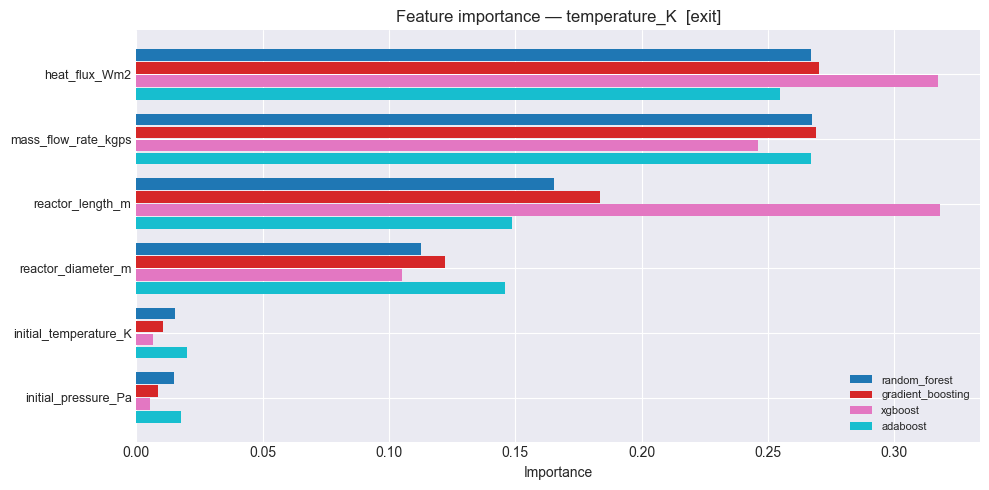

  [bar chart] pressure_Pa  (exit)


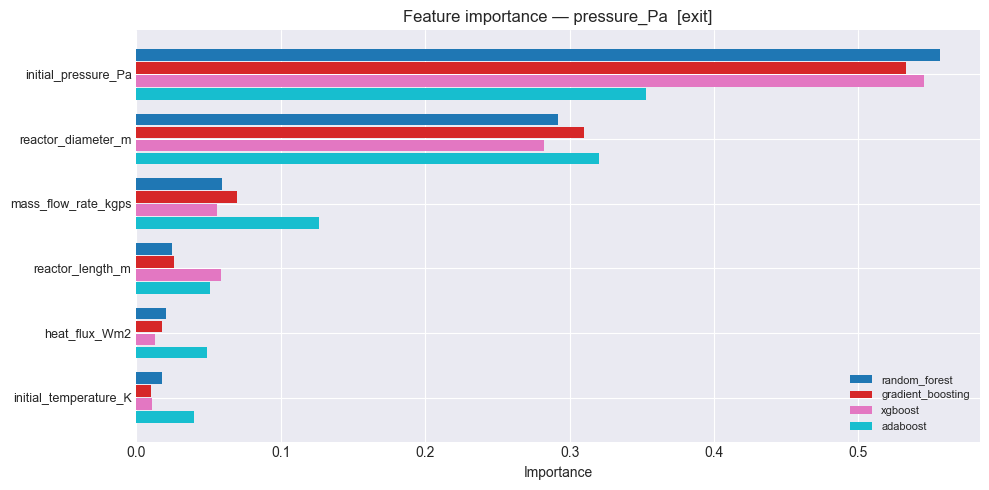

  [bar chart] velocity_ms  (exit)


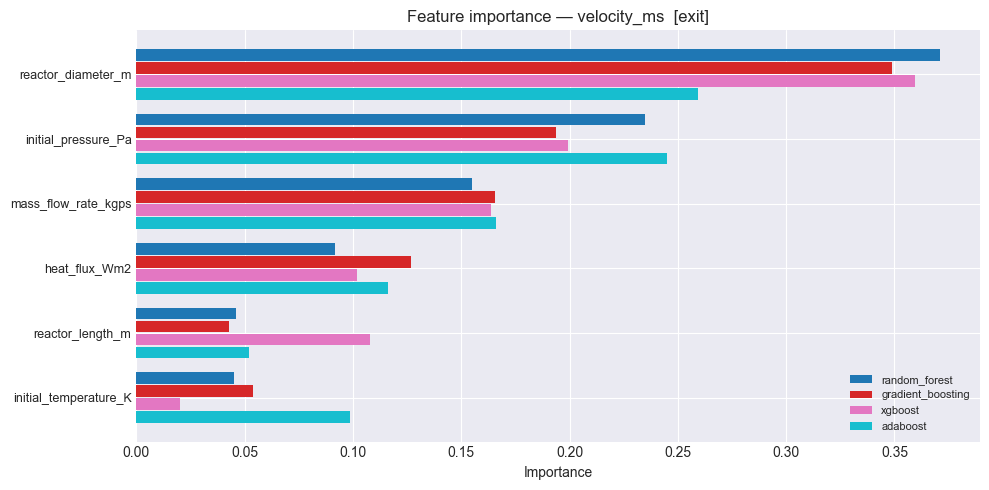

  [bar chart] density_kgm3  (exit)


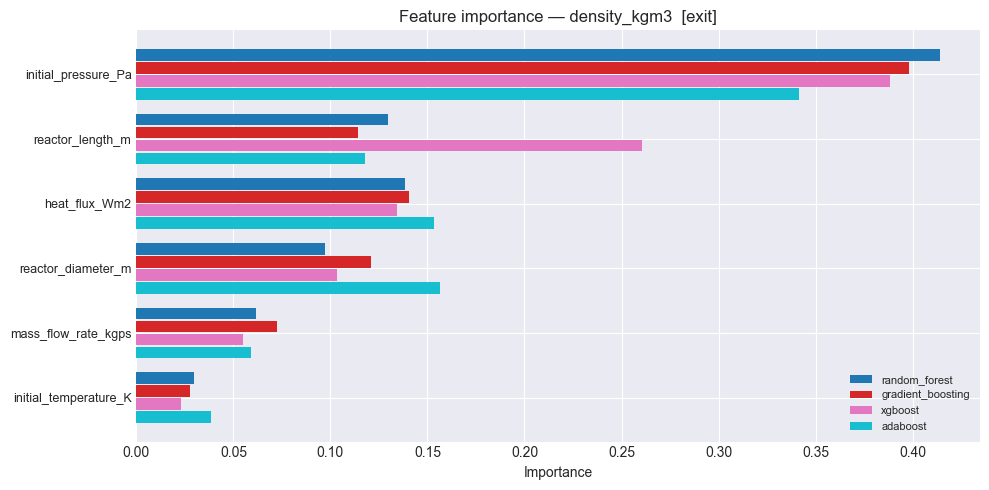

  [bar chart] mean_molecular_weight_kgkmol  (exit)


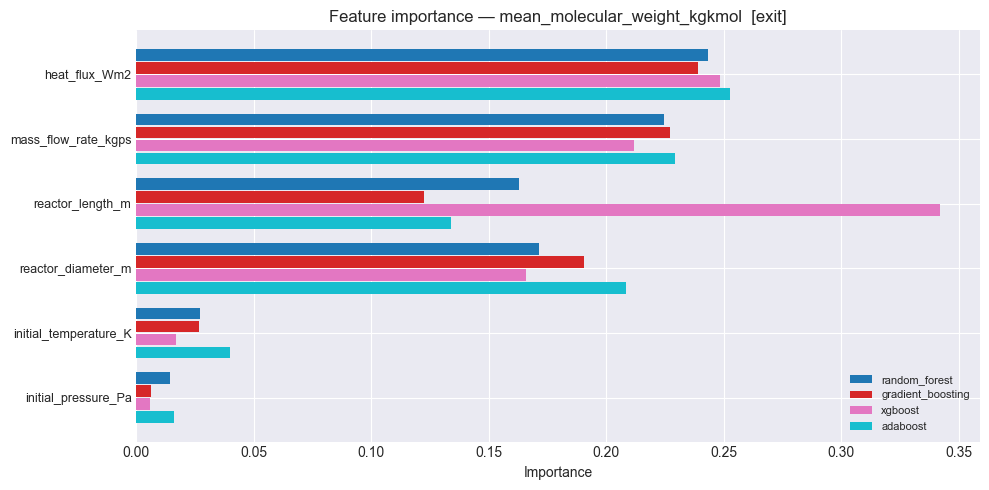

  [bar chart] heat_capacity_cp_JkgK  (exit)


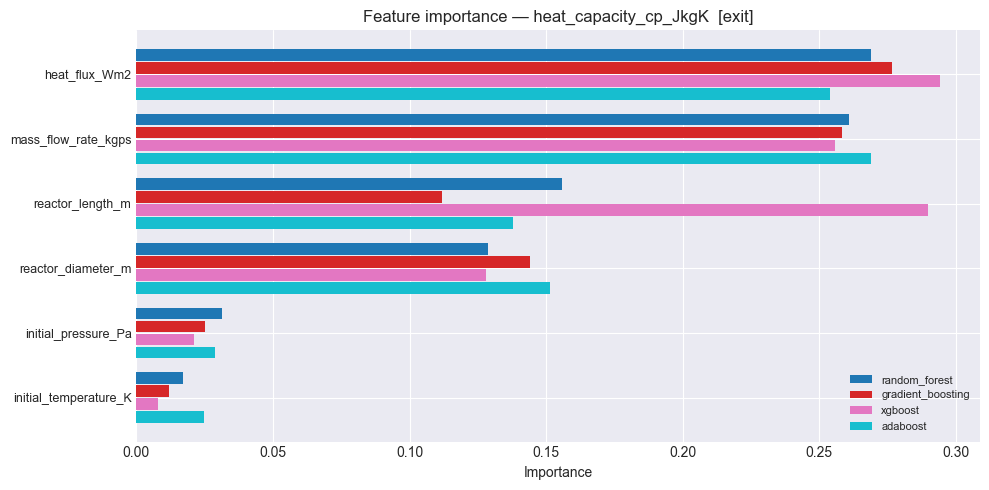

  [bar chart] heat_capacity_cv_JkgK  (exit)


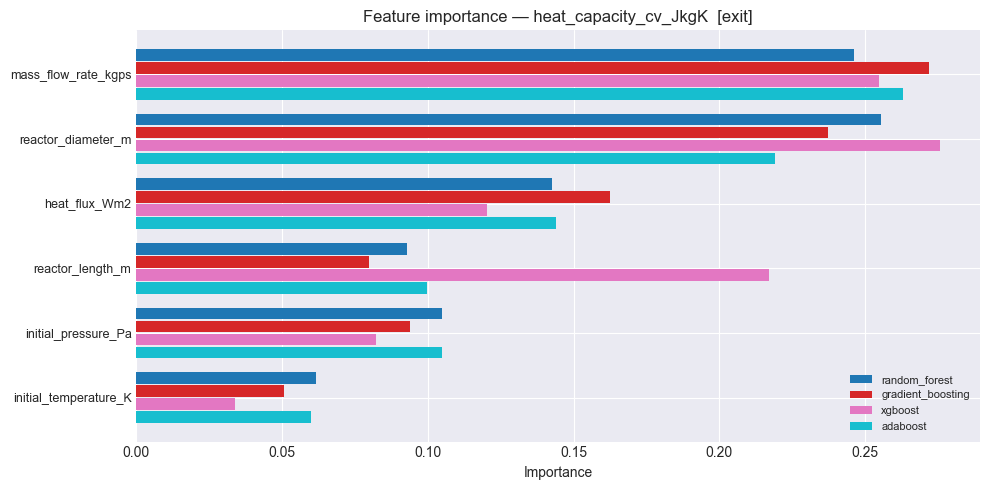

  [bar chart] enthalpy_Jkg  (exit)


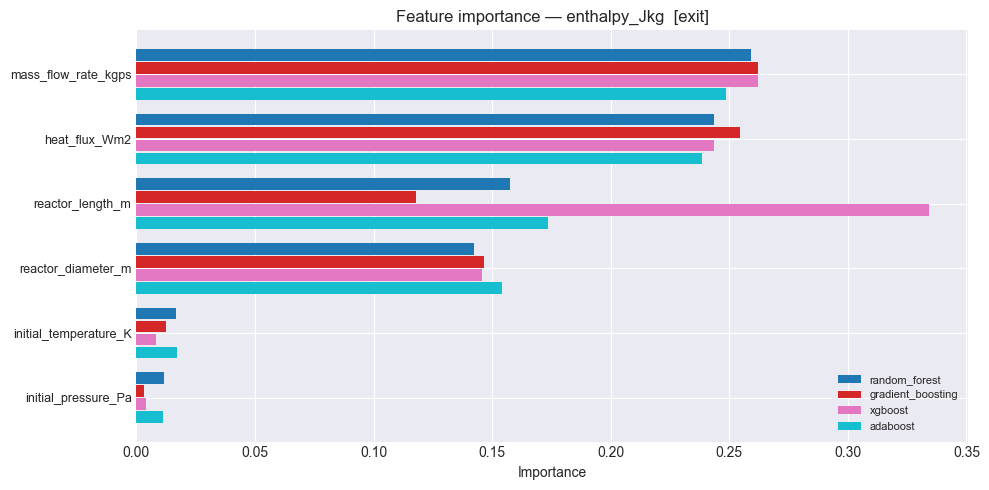

  [bar chart] thermal_conductivity_WmK  (exit)


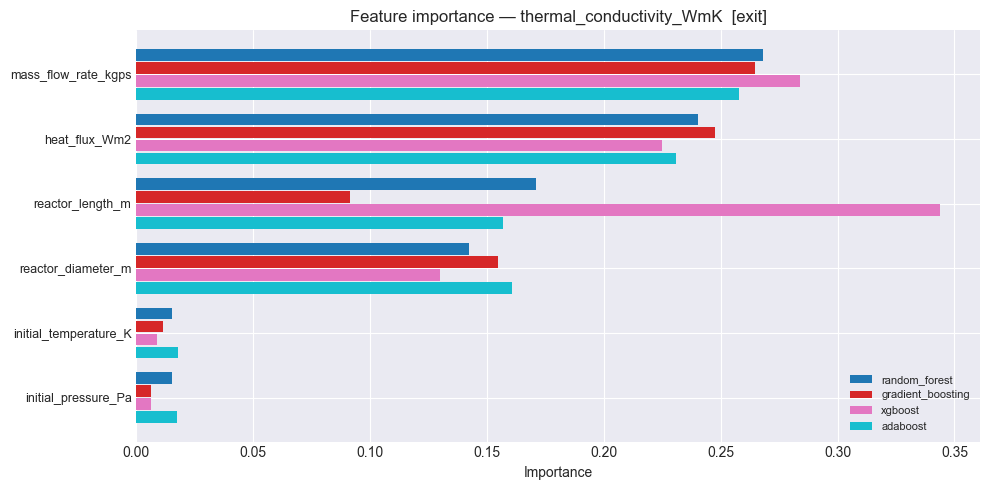


Feature importance — summary
  Save path : /Users/nikolaskarefyllidis/Desktop/60_ML-AI/30 main portofolio projects/HydrAI/outputs/figures
  [exit]  extracted: ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']  |  plotted: ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']
Feature importance plots saved.


In [35]:
def get_feature_importance_per_output(model, model_name, feature_names, output_names):
    """Extract feature importance per output. Returns DataFrame index=features, columns=outputs."""
    print(f"Extracting feature importance per output for {model_name}...")
    n_features = len(feature_names)

    if hasattr(model, 'feature_importances_'):
        # Single-output: one column
        imp = model.feature_importances_
        out_names = [output_names[0]] if output_names else ['output']
        importance_per_output = pd.DataFrame(imp.reshape(-1, 1), index=feature_names, columns=out_names)
    elif hasattr(model, 'estimators_'):
        # MultiOutputRegressor: one column per output (same order as y_train)
        out_names = output_names if len(output_names) == len(model.estimators_) else [f'output_{i}' for i in range(len(model.estimators_))]
        data = np.column_stack([est.feature_importances_ for est in model.estimators_])
        importance_per_output = pd.DataFrame(data, index=feature_names, columns=out_names)
    else:
        raise ValueError(f"{model_name}: cannot get feature importance (no feature_importances_ or estimators_)")

    return importance_per_output


def plot_feature_importance_bars_per_output(importance_dict, top_n=10, save_dir=None, mode_label=''):
    """
    Bar-chart comparison: for each output, one horizontal bar chart with one bar
    per feature, grouped/coloured by model. Lets you see which features matter
    most for each output and how consistently the models agree.

    importance_dict : {model_name: DataFrame(index=features, columns=outputs)}
    """
    model_names = list(importance_dict.keys())
    if not model_names:
        return
    output_names = list(next(iter(importance_dict.values())).columns)
    n_models  = len(model_names)
    colors    = plt.cm.tab10(np.linspace(0, 0.9, n_models))

    for output in output_names:
        print(f"  [bar chart] {output}  ({mode_label})")
        # Collect importances: DataFrame(index=features, columns=models)
        imp_matrix = pd.DataFrame({m: importance_dict[m][output] for m in model_names})
        # Rank features by mean importance across models, keep top_n
        mean_rank = imp_matrix.mean(axis=1).sort_values(ascending=False)
        top_feats = mean_rank.head(top_n).index
        imp_plot  = imp_matrix.loc[top_feats]  # shape (top_n, n_models)

        n_feats   = len(top_feats)
        bar_h     = 0.8 / n_models
        y_pos     = np.arange(n_feats)

        fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * n_feats)))
        for i, (model_name, color) in enumerate(zip(model_names, colors)):
            offsets = y_pos - 0.4 + bar_h * (i + 0.5)
            ax.barh(offsets, imp_plot[model_name], height=bar_h * 0.9,
                    color=color, label=model_name)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_feats, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Importance')
        title = f'Feature importance — {output}'
        if mode_label:
            title += f'  [{mode_label}]'
        ax.set_title(title)
        ax.legend(loc='lower right', fontsize=8)
        plt.tight_layout()
        if IF_PLOT_SHOWN:
            plt.show()
        if IF_PLOT_EXPORT and save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)
            safe_out = output.replace('/', '_').replace(' ', '_')
            path = save_dir / f'bar_{safe_out}.png'
            plt.savefig(path, dpi=300, bbox_inches='tight')
        plt.close()

# ── Section 8: Feature importance per output ───────────────────────────────────
# feature_importance_all[mode][model_name] = DataFrame(index=features, columns=outputs)
feature_importance_all = {}
fig_dir = Path("outputs/figures")

for mode, models in all_models_by_mode.items():
    split             = all_splits[mode]
    ds                = active_datasets[mode]
    feature_names     = split['X_train'].columns.tolist() if hasattr(split['X_train'], 'columns') else [f'Feature_{i}' for i in range(split['X_train'].shape[1])]
    output_names      = split['y_train'].columns.tolist() if hasattr(split['y_train'], 'columns') else [f'output_{i}' for i in range(split['y_train'].shape[1])]
    plot_feature_cols = ds['plot_feature_cols']
    mode_fig_dir      = fig_dir / mode

    print(f"\n  [{mode}] Feature importance")

    # Restrict to selected models when FEATURE_IMPORTANCE_METHOD is a list
    if isinstance(FEATURE_IMPORTANCE_METHOD, (list, tuple)):
        models_to_use = {k: v for k, v in models.items() if k in FEATURE_IMPORTANCE_METHOD}
    else:
        models_to_use = models
    if not models_to_use:
        print(f"  Skipping [{mode}]: no models selected for feature importance.")
        continue

    # Extract importances (filter position cols for exit mode)
    imp_by_model = {}
    for model_name, model in models_to_use.items():
        imp_df = get_feature_importance_per_output(model, model_name, feature_names, output_names)
        imp_by_model[model_name] = imp_df.loc[imp_df.index.intersection(plot_feature_cols)]

    # Restrict to models selected for plotting (FEATURE_IMPORTANCE_METHOD_PLOT)
    if FEATURE_IMPORTANCE_METHOD_PLOT is None:
        imp_for_plot = imp_by_model
    elif isinstance(FEATURE_IMPORTANCE_METHOD_PLOT, str):
        imp_for_plot = {k: v for k, v in imp_by_model.items() if k == FEATURE_IMPORTANCE_METHOD_PLOT}
    else:
        imp_for_plot = {k: v for k, v in imp_by_model.items() if k in FEATURE_IMPORTANCE_METHOD_PLOT}
    if not imp_for_plot:
        print(f"  Skipping plots for [{mode}]: no models in FEATURE_IMPORTANCE_METHOD_PLOT.")
    else:
        # Print feature importance on screen (top 10 features by mean importance, per model)
        top_n_print = 10
        for model_name, imp_df in imp_for_plot.items():
            mean_imp = imp_df.mean(axis=1).sort_values(ascending=False)
            top = mean_imp.head(top_n_print)
            print(f"\n  [{mode}] {model_name} — top {len(top)} features (mean importance)")
            out_cols = list(imp_df.columns)
            for feat in top.index:
                vals = imp_df.loc[feat]
                parts = [f"{feat}:"] + [f"{out_cols[j]}={vals.iloc[j]:.4f}" for j in range(len(out_cols))]
                print("    " + "  |  ".join(parts))
        # Bar chart per output (selected models compared)
        plot_feature_importance_bars_per_output(
            imp_for_plot, top_n=10, save_dir=mode_fig_dir, mode_label=mode
        )

    feature_importance_all[mode] = imp_by_model

# Summary on screen
print("\n" + "=" * 55)
print("Feature importance — summary")
print("=" * 55)
print(f"  Save path : {fig_dir.resolve()}")
for mode, imp_dict in feature_importance_all.items():
    plot_models = list(imp_dict.keys()) if FEATURE_IMPORTANCE_METHOD_PLOT is None else (
        [FEATURE_IMPORTANCE_METHOD_PLOT] if isinstance(FEATURE_IMPORTANCE_METHOD_PLOT, str)
        else [m for m in FEATURE_IMPORTANCE_METHOD_PLOT if m in imp_dict]
    )
    print(f"  [{mode}]  extracted: {list(imp_dict.keys())}  |  plotted: {plot_models}")
print("=" * 55)
print("Feature importance plots saved.")


## 9. Plotting trees

Plot one example tree from a selected model (first output, first tree) for inspection. Controlled by **TREE_PLOT_MODEL** (e.g. `'random_forest'`, `'gradient_boosting'`); **TREE_PLOT_MAX_DEPTH** limits depth for readability. Saved under `outputs/figures/` when export is on.

In [36]:
# ── Section 9: Plot one tree from selected model ─────────────────────────────────
if TREE_PLOT_MODEL is None:
    print("Tree plotting skipped (TREE_PLOT_MODEL is None).")
else:
    mode = next(iter(all_models_by_mode))
    if TREE_PLOT_MODEL not in all_models_by_mode[mode]:
        print(f"Tree plotting skipped: '{TREE_PLOT_MODEL}' not in all_models_by_mode.")
    else:
        wrap = all_models_by_mode[mode][TREE_PLOT_MODEL]
        est = wrap.estimators_[0]  # first output (MultiOutputRegressor)
        feature_names = all_splits[mode]['X_train'].columns.tolist()
        output_names = all_splits[mode]['y_train'].columns.tolist()
        out_name = output_names[0] if output_names else "output_0"

        # First tree: RF has est.estimators_[0]; GB has est.estimators_[0, 0]
        if hasattr(est, 'estimators_') and len(est.estimators_) > 0:
            first_tree = np.asarray(est.estimators_).flat[0]
        else:
            first_tree = est

        fig, ax = plt.subplots(figsize=(14, 8))
        plot_tree(
            first_tree,
            max_depth=TREE_PLOT_MAX_DEPTH,
            feature_names=feature_names,
            filled=True,
            impurity=False,
            node_ids=True,
            ax=ax,
            fontsize=8,
        )
        ax.set_title(f"Tree 0 — {TREE_PLOT_MODEL} [{mode}] — {out_name}")
        plt.tight_layout()
        if IF_PLOT_SHOWN:
            plt.show()
        if IF_PLOT_EXPORT:
            fig_dir = Path("outputs/figures")
            fig_dir.mkdir(parents=True, exist_ok=True)
            path = fig_dir / f"tree_{TREE_PLOT_MODEL}_{mode}.png"
            plt.savefig(path, dpi=150, bbox_inches='tight')
            print(f"Tree plot saved: {path}")
        plt.close()
        print(f"Plotted first tree for {TREE_PLOT_MODEL} [{mode}] (output: {out_name}, max_depth={TREE_PLOT_MAX_DEPTH}).")

Tree plotting skipped (TREE_PLOT_MODEL is None).


## 10. Export models and evaluation data

When **IF_TREE_MODEL_EXPORT** is True, serialize trained models, scalers, and the train/test split so that downstream notebooks (Main_5) can evaluate without re-training.

In [37]:
# ── Section 10: Export models and evaluation data ─────────────────────────────
import joblib
from datetime import datetime

if IF_TREE_MODEL_EXPORT:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    for mode, models in all_models_by_mode.items():
        split = all_splits[mode]
        artifact = {
            'models':       models,
            'scaler_X':     split['scaler_X'],
            'X_train':      split['X_train'],
            'X_test':       split['X_test'],
            'y_train':      split['y_train'],
            'y_test':       split['y_test'],
            'X_train_s':    split['X_train_s'],
            'X_test_s':     split['X_test_s'],
            'feature_cols': split['X_train'].columns.tolist(),
            'target_cols':  split['y_train'].columns.tolist(),
        }
        path = EXPORT_DIR / f"tree_models_{mode}_{ts}.joblib"
        joblib.dump(artifact, path)
        print(f"  [{mode}] Saved → {path}  ({list(models.keys())})")

    print(f"\nAll artifacts exported to {EXPORT_DIR.resolve()}")
else:
    print("Model export disabled (IF_TREE_MODEL_EXPORT = False).")


  [exit] Saved → /Users/nikolaskarefyllidis/Desktop/60_ML-AI/30 main portofolio projects/HydrAI/models/tree_models_exit_20260228_203325.joblib  (['random_forest', 'gradient_boosting', 'xgboost', 'adaboost'])

All artifacts exported to /Users/nikolaskarefyllidis/Desktop/60_ML-AI/30 main portofolio projects/HydrAI/models
